# PRM Demo: Build and Query a Roadmap

This notebook is designed as a self-learning walkthrough for PRM (Probabilistic Roadmap).

What you will learn:
- why PRM separates a "build roadmap" phase and a "query" phase,
- how sampling density and graph connectivity affect success,
- how shortest-path search is run on the sampled roadmap.

How to use this notebook:
1. Run each cell in order.
2. After each stage, inspect outputs before moving on.
3. At the end, change `num_samples` and `k_neighbors` and observe behavior changes.

In [1]:
%matplotlib inline

import math
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

## 1. Create an environment and define the query

In this section we create a 2D occupancy map with obstacles, then define `start` and `goal`.

Focus question:
- Is there at least one clear corridor from start to goal?

In [2]:
H, W = 60, 60
grid = np.zeros((H, W), dtype=np.uint8)

# Obstacles
grid[10:50, 20] = 1
grid[10:50, 40] = 1
grid[30, 20:41] = 1
grid[14, 20] = 0
grid[46, 40] = 0
grid[30, 30] = 0

start = (4, 4)
goal = (55, 55)

## 2. Geometry and collision-check helpers

PRM needs local checks to connect nodes safely.

Key idea:
- `line_free(a, b)` acts as a local planner that approves or rejects an edge.

In [3]:
def in_bounds(r, c):
    return 0 <= r < H and 0 <= c < W

def free_cell(p):
    r, c = p
    return in_bounds(r, c) and grid[r, c] == 0

def line_free(a, b):
    r0, c0 = a
    r1, c1 = b
    n = int(max(abs(r1 - r0), abs(c1 - c0))) + 1
    for i in range(n + 1):
        t = i / max(1, n)
        rr = int(round(r0 + t * (r1 - r0)))
        cc = int(round(c0 + t * (c1 - c0)))
        if not free_cell((rr, cc)):
            return False
    return True

def dist(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

## 3. Sample free nodes and build the roadmap graph

This is the PRM "offline" stage.
- Sample valid points in free space.
- Connect each sample to nearby neighbors if the local edge is collision-free.

Watch:
- Higher `num_samples` improves connectivity but increases compute.
- Higher `k_neighbors` can reduce disconnected components.

In [4]:
rng = random.Random(7)
num_samples = 320
k_neighbors = 10

samples = [start, goal]
while len(samples) < num_samples + 2:
    p = (rng.randrange(H), rng.randrange(W))
    if free_cell(p):
        samples.append(p)

G = nx.Graph()
for i, p in enumerate(samples):
    G.add_node(i, pos=p)

for i, p in enumerate(samples):
    nbrs = sorted(((dist(p, q), j) for j, q in enumerate(samples) if j != i), key=lambda x: x[0])[:k_neighbors]
    for d, j in nbrs:
        q = samples[j]
        if line_free(p, q):
            G.add_edge(i, j, weight=d)

print('Nodes:', G.number_of_nodes(), 'Edges:', G.number_of_edges())

Nodes: 322 Edges: 1784


## 4. Solve a shortest-path query on the roadmap

Now we switch to the "online query" stage: connect start and goal (already included as nodes) and run shortest-path search on the graph.

Interpretation tip:
- If this step fails, roadmap connectivity is usually the issue, not path-search logic.

In [5]:
start_id, goal_id = 0, 1
try:
    path_ids = nx.shortest_path(G, source=start_id, target=goal_id, weight='weight')
    path = [samples[i] for i in path_ids]
    path_len = sum(dist(path[i], path[i + 1]) for i in range(len(path) - 1))
    print('Path nodes:', len(path), 'Path length:', round(path_len, 2))
except nx.NetworkXNoPath:
    path = None
    print('No roadmap path found.')

Path nodes: 19 Path length: 88.32


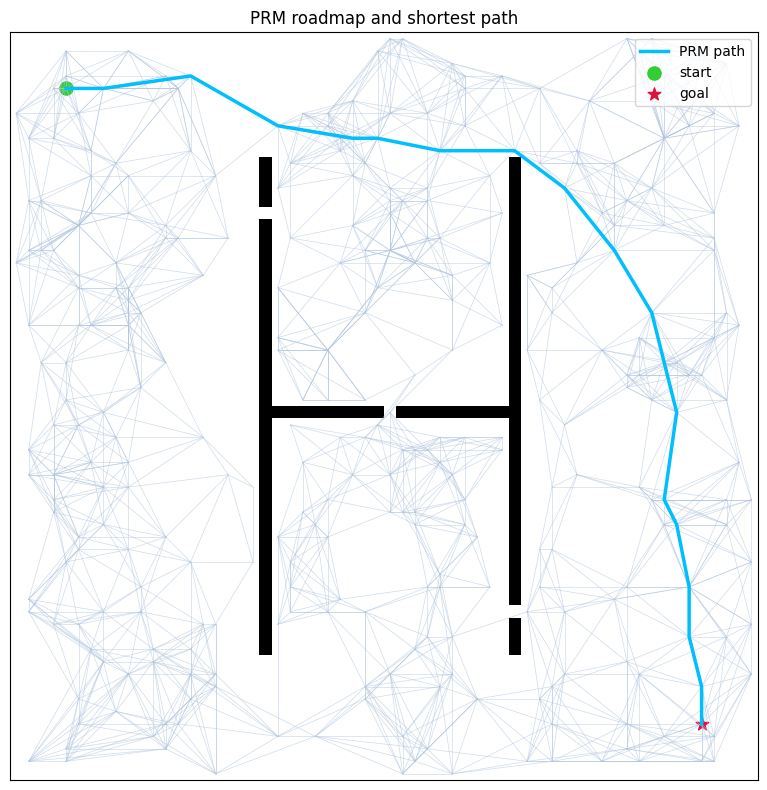

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grid, cmap='Greys', origin='upper')

for u, v in G.edges():
    (r1, c1), (r2, c2) = samples[u], samples[v]
    ax.plot([c1, c2], [r1, r2], color='lightsteelblue', linewidth=0.5, alpha=0.6)

if path is not None:
    px = [p[1] for p in path]
    py = [p[0] for p in path]
    ax.plot(px, py, color='deepskyblue', linewidth=2.5, label='PRM path')
else:
    ax.text(0.02, 0.98, 'No roadmap path found', transform=ax.transAxes, va='top', ha='left', color='crimson', bbox=dict(facecolor='white', alpha=0.8, edgecolor='crimson'))

ax.scatter(start[1], start[0], c='limegreen', s=90, marker='o', label='start')
ax.scatter(goal[1], goal[0], c='crimson', s=90, marker='*', label='goal')
ax.set_title('PRM roadmap and shortest path')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()